In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look a bit more professional
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# The '..' means go up one folder from 'notebooks/', then into 'data/'
raw_data_path = '../data/dataset.xlsx'

df_raw = pd.read_excel(raw_data_path, header=3, engine='openpyxl')

# first 5 rows
df_raw.head()

,Date,RW pH,TW pH,RW Tur,TW Tur,TW FRC,RW Colour,TW Colour,RW TDS,TW TDS,...,RW Alkalinity,TW Alkalinity,RW Ammonia as N,TW Ammonia as N,RW Total algal counts,TW Total algal counts,RW Fecal coliform,TW Fecal coliform,RW Total coliform,TW Total coliform
0,Norms : Design (RW) \n/ CPHEEO (TW),6.00 - 8.40,7.00 - 8.00,<30,<1,Min 0.2,20,5,370,500,...,30 -120,200,0.700,0.500,10000000,NaN,1800,2,1800,2
1,2024-04-01 00:00:00,8.005417,7.744583,4.15,0.962083,1.045417,9,3,321,335,...,157,138,0.139,0.113,20000000,Nil,1800,2,1800,2
2,2024-04-02 00:00:00,8.012083,7.690417,5.0375,0.960417,0.910833,9,3,341,348,...,163,148,0.132,0.105,20000000,Nil,1800,2,1800,2
3,2024-04-03 00:00:00,8.028333,7.695833,4.682917,0.972917,1.090833,8,3,330,335,...,162,148,0.138,0.104,24000000,Nil,1800,2,1800,2
4,2024-04-04 00:00:00,7.9775,7.695,4.779583,0.969167,1.11625,8,3,352,357,...,157,148,0.120,0.094,24000000,Nil,1800,2,1800,2


In [4]:
# Extract the first row (the norms) and save it separately
norms_df = df_raw.iloc[0:1].copy()

# Keep everything from row 1 downwards as our actual working data
df = df_raw.iloc[1:].copy()

print("Norms separated. Working dataset shape:", df.shape)
df.head(3)

Norms separated. Working dataset shape: (426, 42)


,Date,RW pH,TW pH,RW Tur,TW Tur,TW FRC,RW Colour,TW Colour,RW TDS,TW TDS,...,RW Alkalinity,TW Alkalinity,RW Ammonia as N,TW Ammonia as N,RW Total algal counts,TW Total algal counts,RW Fecal coliform,TW Fecal coliform,RW Total coliform,TW Total coliform
1,2024-04-01 00:00:00,8.005417,7.744583,4.15,0.962083,1.045417,9,3,321,335,...,157,138,0.139,0.113,20000000,Nil,1800,2,1800,2
2,2024-04-02 00:00:00,8.012083,7.690417,5.0375,0.960417,0.910833,9,3,341,348,...,163,148,0.132,0.105,20000000,Nil,1800,2,1800,2
3,2024-04-03 00:00:00,8.028333,7.695833,4.682917,0.972917,1.090833,8,3,330,335,...,162,148,0.138,0.104,24000000,Nil,1800,2,1800,2


In [5]:
# 1. Replace the word 'Nil' with the number '0' in the entire table
df = df.replace('Nil', '0')

# 2. Convert all columns (except the 'Date' column) to numeric types (Floats)
for col in df.columns:
    if col != 'Date':
        # errors='coerce' means if it finds any other weird text, turn it into a NaN (Null)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Convert the 'Date' column to actual datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 4. Drop any rows that are completely empty or corrupted
df = df.dropna().reset_index(drop=True)

# Let's check our clean data types!
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422 entries, 0 to 421
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   422 non-null    datetime64[ns]
 1   RW pH                  422 non-null    float64       
 2   TW pH                  422 non-null    float64       
 3   RW Tur                 422 non-null    float64       
 4   TW Tur                 422 non-null    float64       
 5   TW FRC                 422 non-null    float64       
 6   RW Colour              422 non-null    int64         
 7   TW Colour              422 non-null    int64         
 8   RW TDS                 422 non-null    int64         
 9   TW TDS                 422 non-null    int64         
 10  RW Iron                422 non-null    float64       
 11  TW Iron                422 non-null    float64       
 12  RW Hardness            422 non-null    int64         
 13  TW Ha

C:\Users\Vijayasimha\AppData\Local\Temp\ipykernel_29416\253638478.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('Nil', '0')


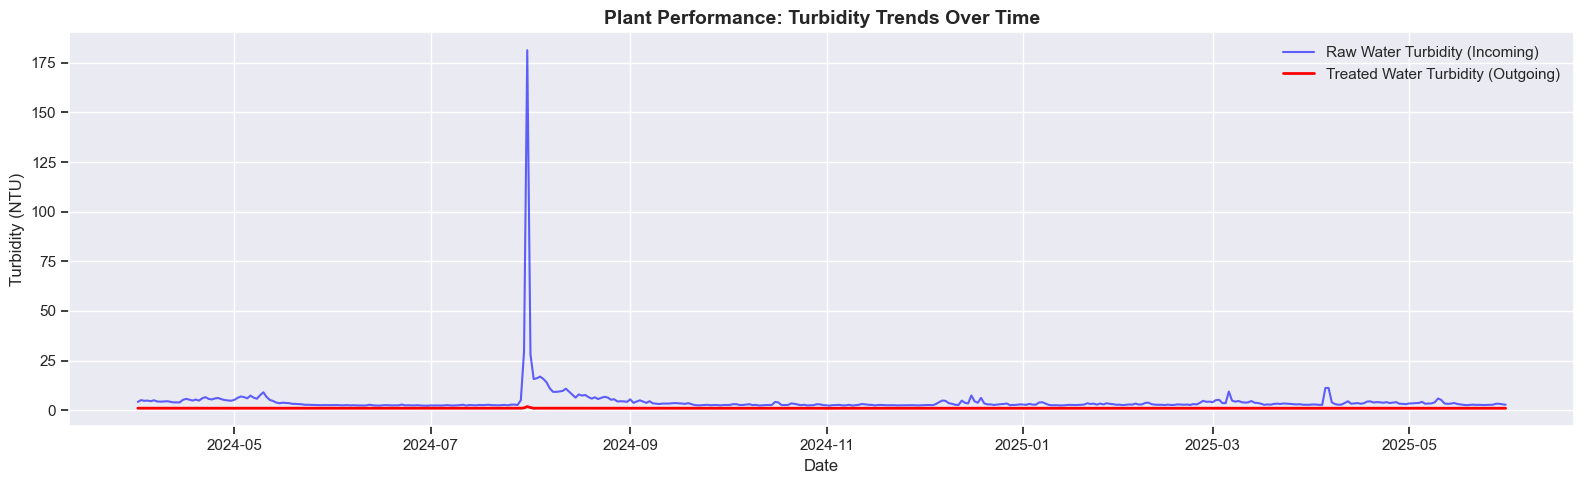

In [6]:
# Create a wide canvas
plt.figure(figsize=(16, 5))

# Plot Raw Water vs Treated Water Turbidity over time
plt.plot(df['Date'], df['RW Tur'], label='Raw Water Turbidity (Incoming)', color='blue', alpha=0.6)
plt.plot(df['Date'], df['TW Tur'], label='Treated Water Turbidity (Outgoing)', color='red', linewidth=2)

plt.title('Plant Performance: Turbidity Trends Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Turbidity (NTU)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

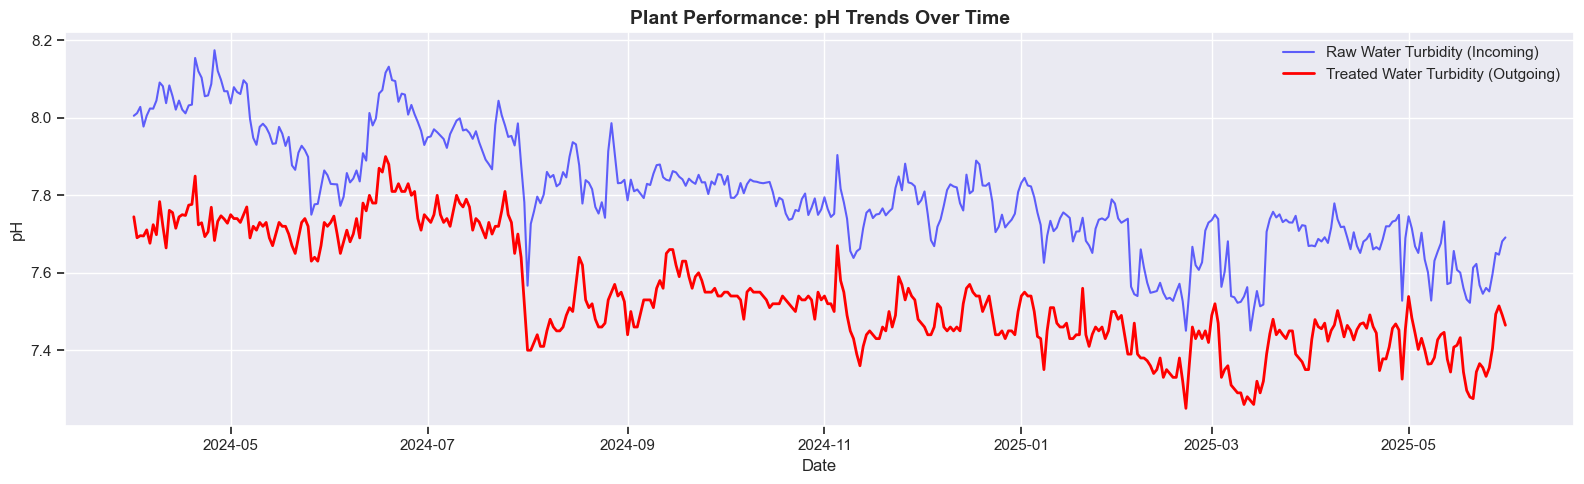

In [7]:
# Create a wide canvas
plt.figure(figsize=(16, 5))

# Plot Raw Water vs Treated Water pH over time
plt.plot(df['Date'], df['RW pH'], label='Raw Water Turbidity (Incoming)', color='blue', alpha=0.6)
plt.plot(df['Date'], df['TW pH'], label='Treated Water Turbidity (Outgoing)', color='red', linewidth=2)

plt.title('Plant Performance: pH Trends Over Time', fontsize=14, fontweight='bold')
plt.ylabel('pH')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

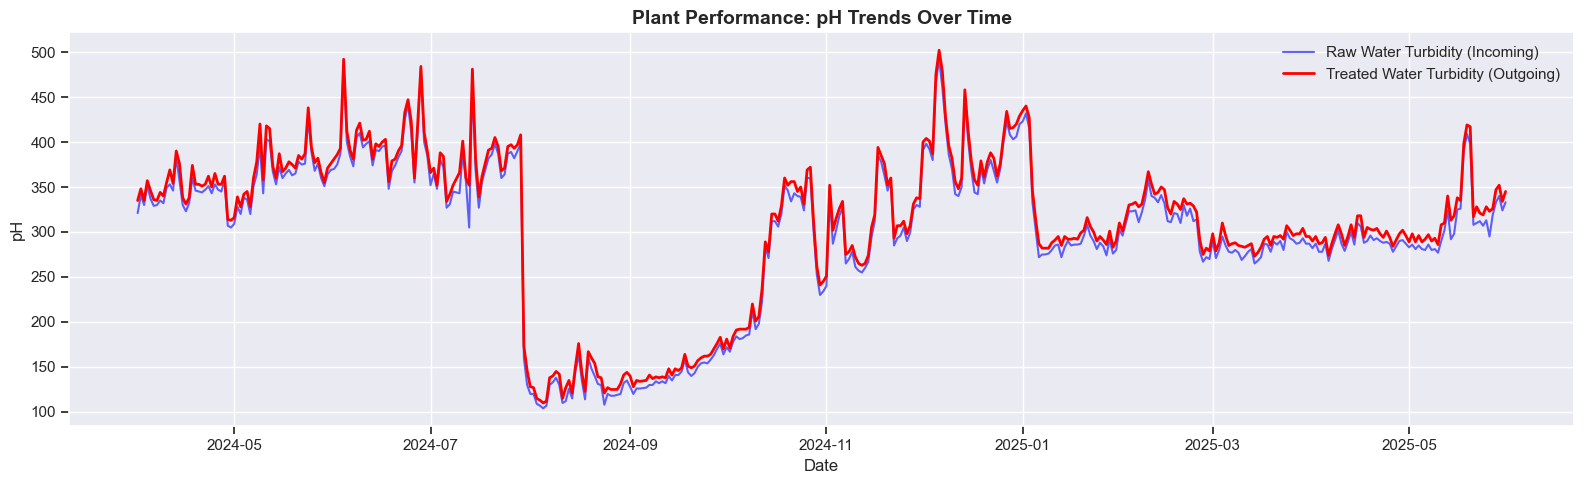

In [8]:
# Create a wide canvas
plt.figure(figsize=(16, 5))

# Plot Raw Water vs Treated Water TDS over time
plt.plot(df['Date'], df['RW TDS'], label='Raw Water Turbidity (Incoming)', color='blue', alpha=0.6)
plt.plot(df['Date'], df['TW TDS'], label='Treated Water Turbidity (Outgoing)', color='red', linewidth=2)

plt.title('Plant Performance: pH Trends Over Time', fontsize=14, fontweight='bold')
plt.ylabel('TDS')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

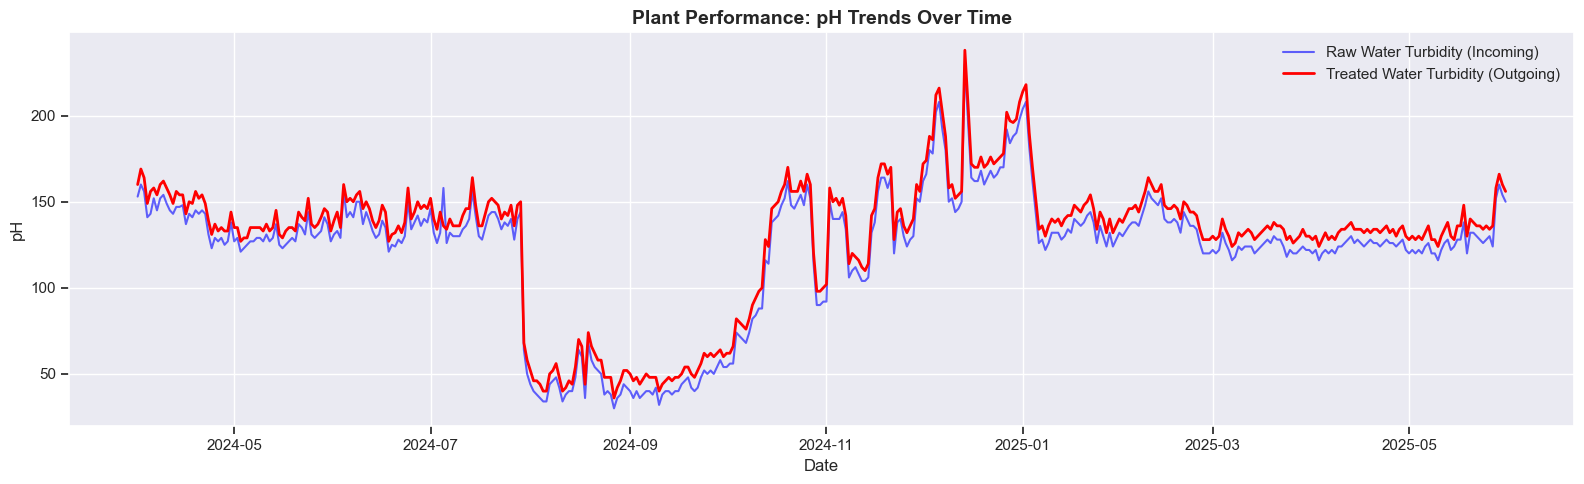

In [9]:
# Create a wide canvas
plt.figure(figsize=(16, 5))

# Plot Raw Water vs Treated Water Hardness over time
plt.plot(df['Date'], df['RW Hardness'], label='Raw Water Turbidity (Incoming)', color='blue', alpha=0.6)
plt.plot(df['Date'], df['TW Hardness'], label='Treated Water Turbidity (Outgoing)', color='red', linewidth=2)

plt.title('Plant Performance: pH Trends Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Hardness')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

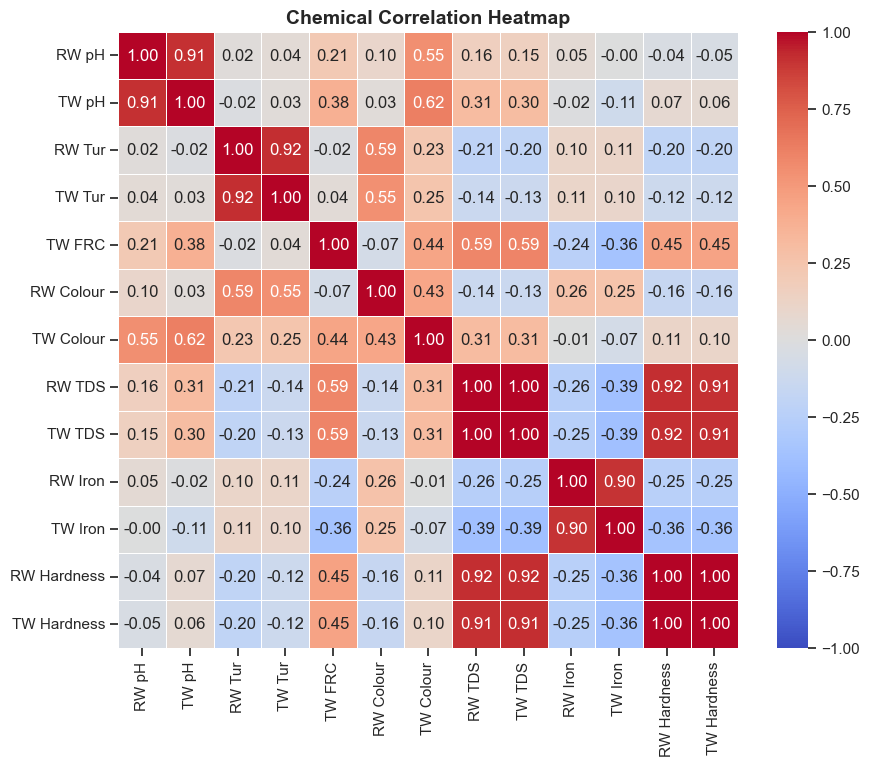

In [9]:
# Select a targeted list of core chemical columns
core_metrics = [
    'RW pH','TW pH','RW Tur','TW Tur','TW FRC','RW Colour','TW Colour','RW TDS','TW TDS','RW Iron','TW Iron','RW Hardness','TW Hardness'
]

# Calculate the correlation matrix
corr_matrix = df[core_metrics].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Chemical Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

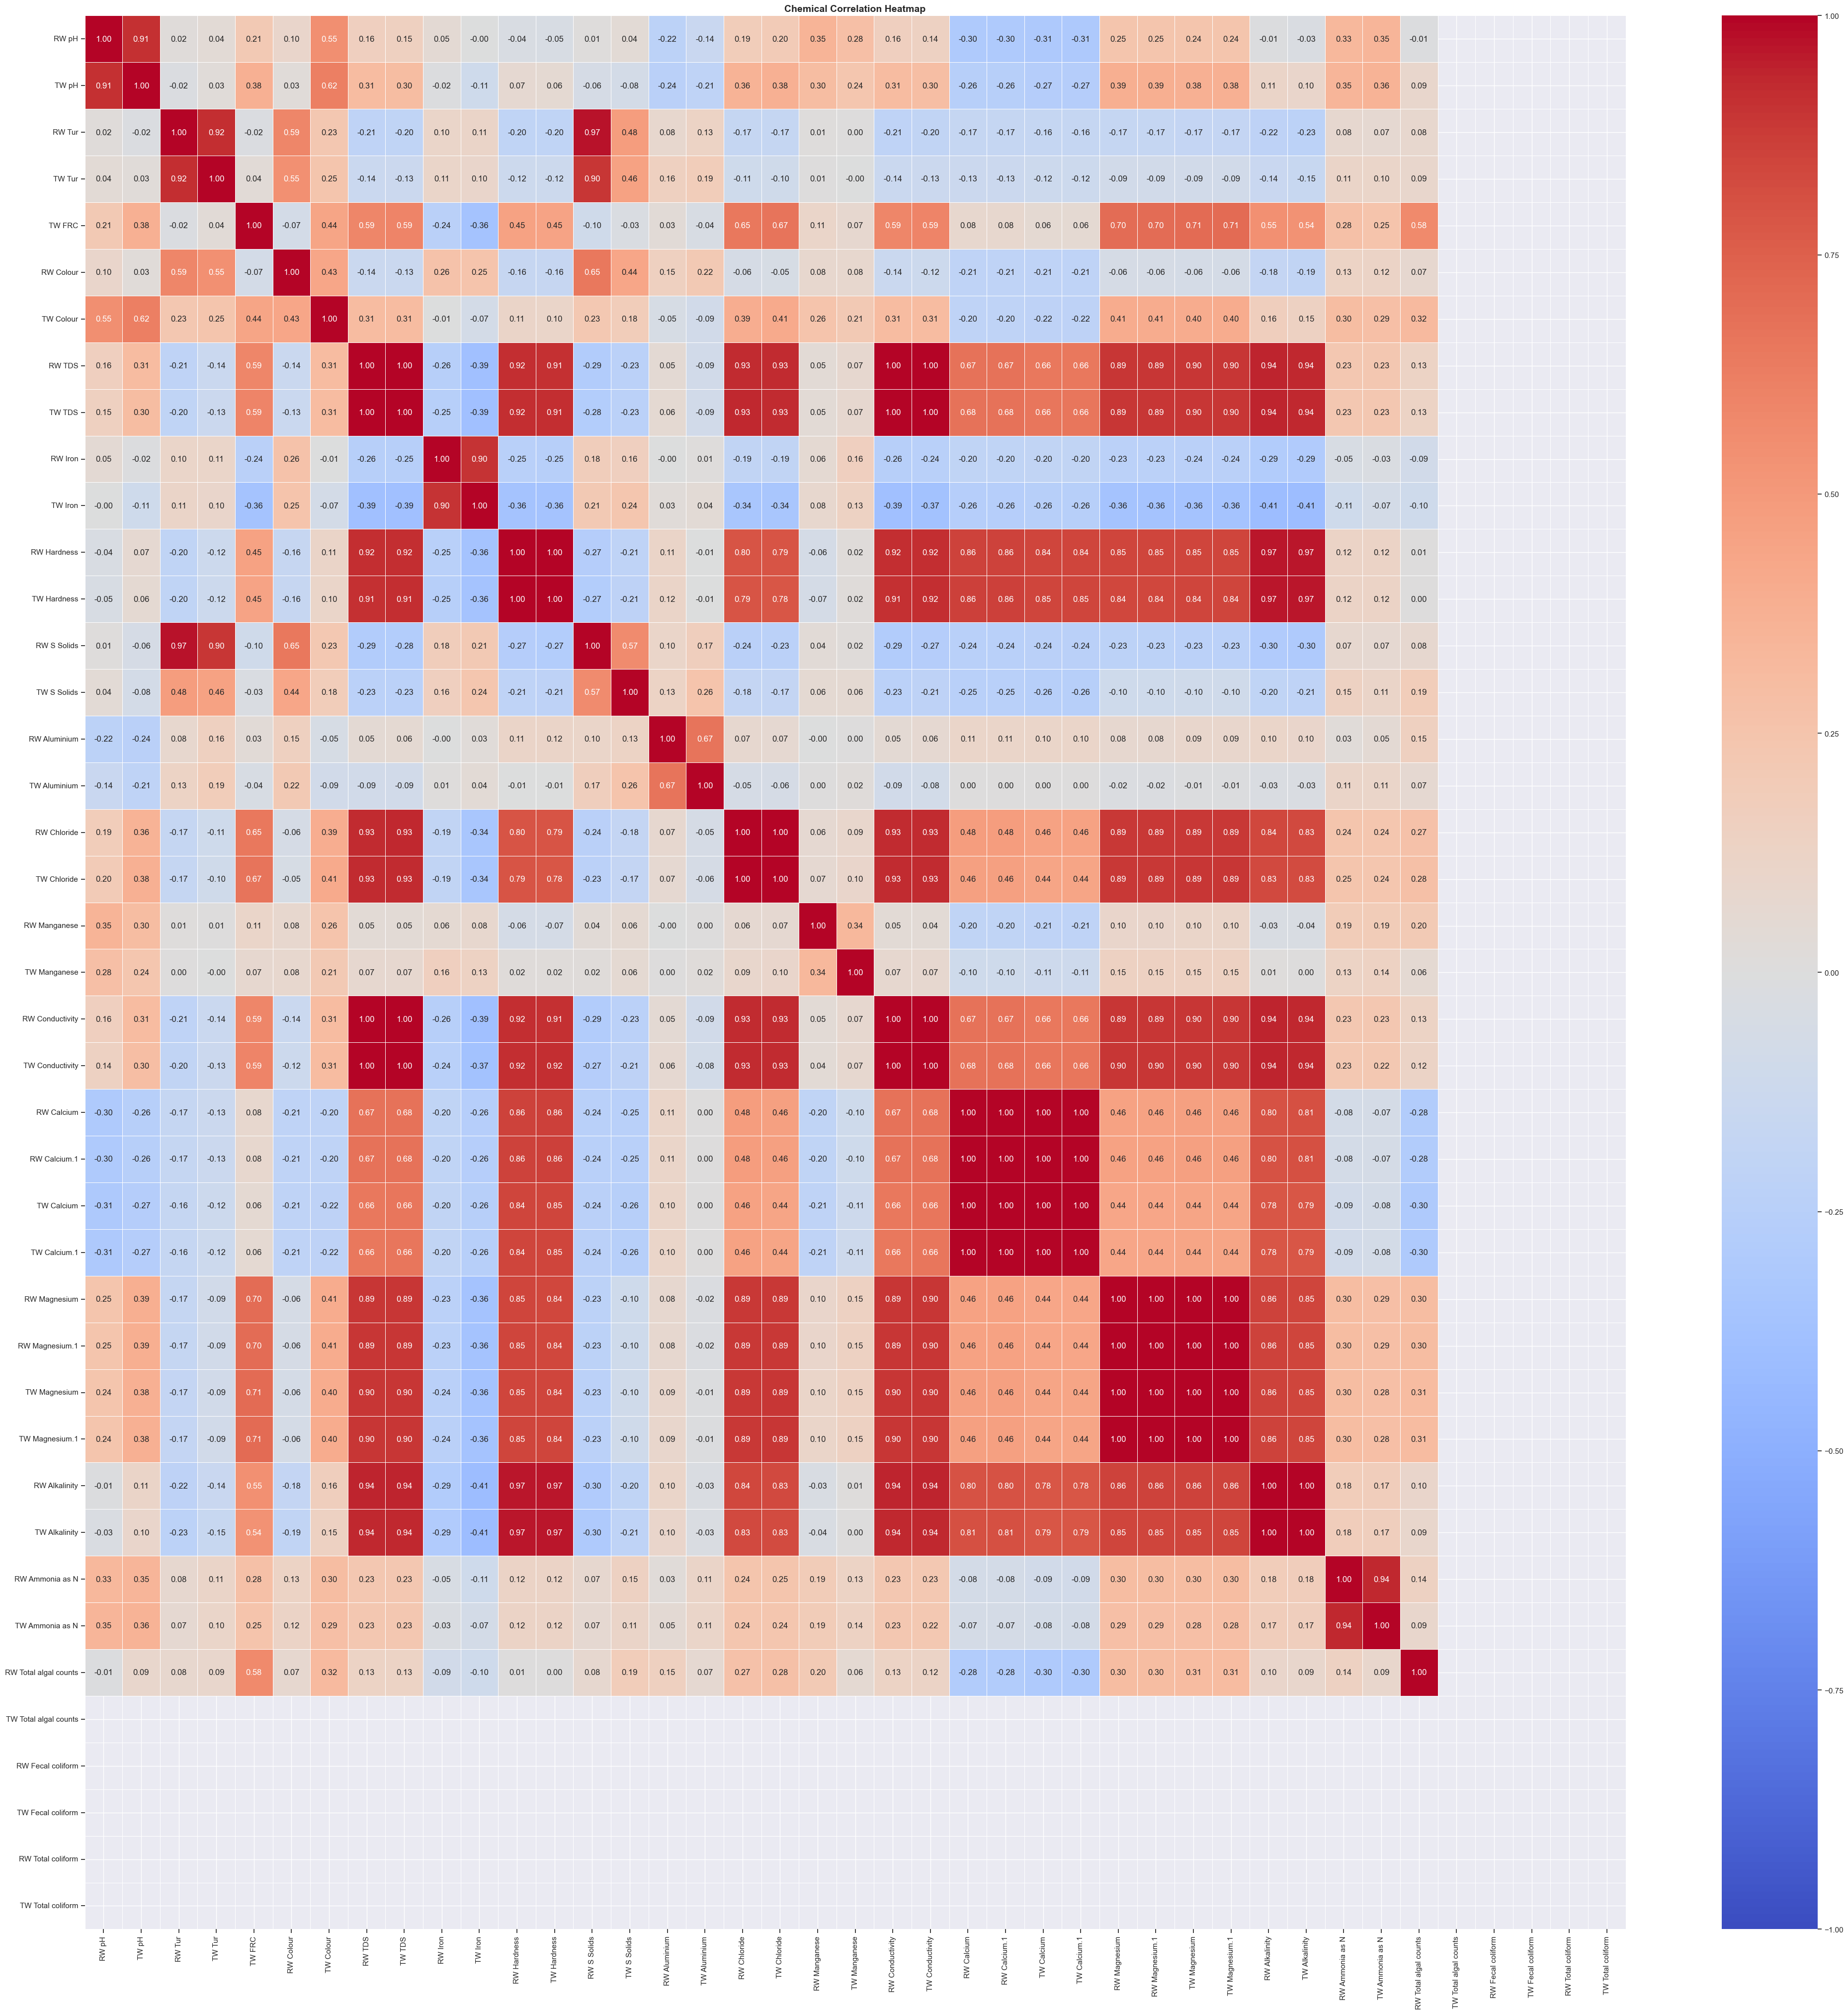

In [10]:
# Select a targeted list of core chemical columns
core_metrics = [
   'RW pH','TW pH','RW Tur','TW Tur','TW FRC','RW Colour','TW Colour','RW TDS','TW TDS','RW Iron','TW Iron','RW Hardness','TW Hardness',
    'RW S Solids','TW S Solids','RW Aluminium','TW Aluminium','RW Chloride','TW Chloride','RW Manganese','TW Manganese','RW Conductivity',
    'TW Conductivity','RW Calcium','RW Calcium.1','TW Calcium','TW Calcium.1','RW Magnesium','RW Magnesium.1','TW Magnesium','TW Magnesium.1',
    'RW Alkalinity','TW Alkalinity','RW Ammonia as N','TW Ammonia as N','RW Total algal counts', 'TW Total algal counts','RW Fecal coliform',
    'TW Fecal coliform','RW Total coliform','TW Total coliform']

# Calculate the correlation matrix
corr_matrix = df[core_metrics].corr()

# Plot the heatmap
plt.figure(figsize=(50, 50))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Chemical Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [11]:
# Drop both RW and TW algal counts columns
columns_to_drop = ['RW Total algal counts', 'TW Total algal counts','RW Fecal coliform','TW Fecal coliform',
                   'RW Total coliform','TW Total coliform','RW Calcium.1','TW Calcium.1','RW Magnesium.1','TW Magnesium.1']
df = df.drop(columns=columns_to_drop)

print("After dropping columns : ", df.shape)

After dropping columns :  (422, 32)


In [13]:
import os

# 1. Define the output paths
clean_data_path = '../data/cleaned_water_data.csv'
norms_path = '../data/cpheeo_norms.csv'

# 2. Save the cleaned working data
# index=False prevents pandas from writing the row numbers (0, 1, 2...) as a new column
df.to_csv(clean_data_path, index=False)

# 3. Save the separated norms/rules
norms_df.to_csv(norms_path, index=False)

print(f"Success! Clean data saved to: {clean_data_path}")
print(f"Success! Norms saved to: {norms_path}")

Success! Clean data saved to: ../data/cleaned_water_data.csv
Success! Norms saved to: ../data/cpheeo_norms.csv
